![Banner GIF](https://drive.google.com/uc?export=view&id=1oHukTQ2TohQMlmcFhwc8q1ZGqcfb7nPq)

## Objetivo

Este notebook documenta de manera reproducible el análisis estadístico y computacional desarrollado en la presente tesis doctoral, cuyo propósito es evaluar comparativamente el desempeño de distintos modelos de aprendizaje automático aplicados a la predicción de enfermedad cardíaca a partir de variables clínicas estructuradas.

En particular, se analizan los siguientes modelos:

- Regresión logística

- Random Forest

- Gradient Boosting

El desempeño predictivo de los modelos se evalúa mediante esquemas de validación cruzada estratificada y repetida, con el fin de garantizar estabilidad y reducir sesgos asociados a la partición de los datos. Adicionalmente, se emplean procedimientos de inferencia estadística, incluyendo análisis de varianza (ANOVA) y la prueba no paramétrica de Friedman, con el objetivo de determinar si las diferencias observadas entre modelos son estadísticamente significativas. El análisis se complementa con la estimación del tamaño del efecto y la evaluación de la capacidad discriminativa mediante curvas ROC y estimaciones del área bajo la curva (AUC), siguiendo recomendaciones metodológicas ampliamente aceptadas en estudios clínicos basados en aprendizaje automático.

**1. Instalación e importación de librerías**

En esta sección se importan las librerías necesarias para el desarrollo del análisis estadístico y computacional. Se emplean herramientas estándar de ciencia de datos y aprendizaje automático en Python, ampliamente utilizadas y validadas en la literatura científica. Estas librerías permiten realizar el preprocesamiento de datos, la implementación de modelos predictivos, la evaluación de métricas de desempeño y la ejecución de pruebas inferenciales.

Se fija una semilla aleatoria con el fin de garantizar la reproducibilidad de los resultados, siguiendo buenas prácticas en investigación computacional.

In [ ]:
# Librerías para análisis estadístico y aprendizaje automático
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from scipy.stats import f_oneway, pearsonr
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare
from sklearn.metrics import roc_curve

***1.1 Dependencias adicionales***

In [ ]:
# statsmodels se utiliza para pruebas post hoc; se asume instalado en el entorno de ejecución
!pip install statsmodels

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Versión sklearn:", sklearn.__version__)

Versión sklearn: 1.6.1


**2. Carga y descripción dataset**

 ***2.1 Conjunto de datos***

El análisis se realiza utilizando el conjunto de datos Cleveland Heart Disease, uno de los datasets clínicos más empleados en la evaluación de algoritmos de aprendizaje automático aplicados a la predicción de enfermedad cardíaca. El conjunto contiene variables clínicas estructuradas y una variable objetivo que indica la presencia o ausencia de enfermedad cardíaca.

Los datos fueron obtenidos desde el repositorio público de la [UCI Machine Learning Repository](https://www.archive.ics.uci.edu/about?utm_source=chatgpt.com), garantizando transparencia y reproducibilidad del estudio.
Este notebook constituye un anexo metodológico reproducible que respalda los resultados reportados en el capítulo 4 de la tesis.

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

data = pd.read_csv(url, names=columns)

data["target"] = data["target"].apply(lambda x: 1 if x > 0 else 0)
data.replace("?", np.nan, inplace=True)
data = data.dropna().astype(float)

print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


**3. Descripción estadística**

Se realizó un análisis estadístico descriptivo con el objetivo de caracterizar la distribución de las variables clínicas incluidas en el estudio. Este análisis permite identificar rangos, tendencias centrales y dispersión de las variables, así como evaluar posibles asimetrías o valores extremos que puedan influir en el desempeño de los modelos predictivos.

La distribución de la variable objetivo fue analizada para evaluar el balance entre clases, aspecto relevante en problemas de clasificación binaria en contextos clínicos.

In [ ]:
desc_stats = data.describe()

display(desc_stats)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


La variable objetivo fue recodificada en formato binario, donde el valor 1 indica presencia de enfermedad cardíaca y 0 su ausencia. Adicionalmente, se eliminaron los registros con valores faltantes, resultando en un conjunto final de datos completamente estructurado y apto para el análisis estadístico y el entrenamiento de modelos predictivos.

In [ ]:
desc_stats = data.describe()
class_distribution = data['target'].value_counts(normalize=True)

desc_stats
class_distribution

,proportion
target,
0.0,0.538721
1.0,0.461279


In [ ]:
desc_stats.to_csv("tabla_descriptiva.csv")

La distribución observada evidencia un leve desbalance entre las clases, aunque dentro de márgenes aceptables para la aplicación de técnicas de aprendizaje supervisado. Este comportamiento justifica el uso de validación cruzada estratificada en las etapas posteriores del análisis.

**4. Preprocesamiento con pipeline**

Con el fin de asegurar un flujo de trabajo reproducible y evitar fugas de información (data leakage), se implementaron pipelines de preprocesamiento y modelado utilizando la estructura propuesta por scikit-learn. En el caso de la regresión logística, se incorporó la normalización de variables numéricas mediante estandarización, dado que este tipo de modelo es sensible a la escala de las variables.

Los modelos basados en árboles (Random Forest y Gradient Boosting) se implementaron sin escalamiento previo, ya que su estructura no requiere normalización de las variables de entrada.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Modelos evaluados según la operacionalización de variables
X = data.drop('target', axis=1)
y = data['target']

pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

pipeline_gb = Pipeline([
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

**5. Validación cruzada**

Para obtener estimaciones robustas del desempeño predictivo y reducir la variabilidad asociada a una única partición del conjunto de datos, se empleó un esquema de validación cruzada estratificada repetida (10 particiones × 5 repeticiones). Este enfoque garantiza que la proporción de clases se mantenga constante en cada partición y permite evaluar la estabilidad de los modelos a través de múltiples iteraciones.

In [ ]:
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=RANDOM_STATE
)

print("Total iteraciones:", 10*5)

Total iteraciones: 50


**6. Evaluación de metricas**

El desempeño de los modelos se evaluó mediante métricas estándar en clasificación binaria: accuracy y área bajo la curva ROC (AUC). Estas métricas permiten evaluar tanto la proporción global de predicciones correctas como la capacidad discriminativa de los modelos en distintos umbrales de decisión.

Las medias y desviaciones estándar obtenidas a partir de las iteraciones de validación cruzada permiten comparar el desempeño promedio y la estabilidad relativa de cada algoritmo.

In [ ]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'roc_auc']

results_log = cross_validate(pipeline_log, X, y, scoring=scoring, cv=cv)
results_rf = cross_validate(pipeline_rf, X, y, scoring=scoring, cv=cv)
results_gb = cross_validate(pipeline_gb, X, y, scoring=scoring, cv=cv)

print("Logistic Accuracy:", results_log['test_accuracy'].mean(), results_log['test_accuracy'].std())
print("Random Forest Accuracy:", results_rf['test_accuracy'].mean(), results_rf['test_accuracy'].std())
print("Gradient Boosting Accuracy:", results_gb['test_accuracy'].mean(), results_gb['test_accuracy'].std())

print("Logistic AUC:", results_log['test_roc_auc'].mean(), results_log['test_roc_auc'].std())
print("Random Forest AUC:", results_rf['test_roc_auc'].mean(), results_rf['test_roc_auc'].std())
print("Gradient Boosting AUC:", results_gb['test_roc_auc'].mean(), results_gb['test_roc_auc'].std())

Logistic Accuracy: 0.8324827586206895 0.06876092641887374
Random Forest Accuracy: 0.8230344827586206 0.07618321436431115
Gradient Boosting Accuracy: 0.7870574712643679 0.0735415952415894
Logistic AUC: 0.9024931318681318 0.05826999375507535
Random Forest AUC: 0.8994642857142857 0.06713903867332166
Gradient Boosting AUC: 0.8695673076923076 0.06694821200438342


In [ ]:
# Scores de accuracy para análisis inferencial
scores_log = results_log['test_accuracy']
scores_rf = results_rf['test_accuracy']
scores_gb = results_gb['test_accuracy']

***6.1 Grafico comparativo***

/tmp/ipython-input-1985314383.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_log, scores_rf, scores_gb],


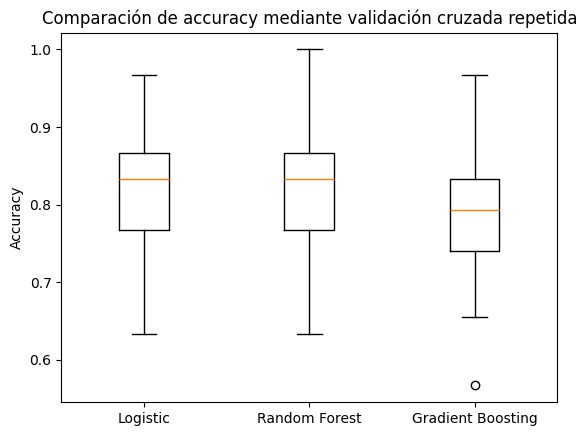

In [ ]:
plt.boxplot([scores_log, scores_rf, scores_gb],
            labels=['Logistic', 'Random Forest', 'Gradient Boosting'])
plt.title("Comparación de accuracy mediante validación cruzada repetida")
plt.ylabel("Accuracy")
plt.savefig("boxplot_modelos.png", dpi=300)
plt.show()

**7. ANOVA**

Con el objetivo de determinar si las diferencias observadas en el desempeño promedio eran estadísticamente significativas, se aplicó un análisis de varianza (ANOVA) de un factor sobre los scores de accuracy obtenidos mediante validación cruzada repetida.

In [ ]:
from scipy.stats import f_oneway

anova_result = f_oneway(scores_log, scores_rf, scores_gb)
print(anova_result)

F_onewayResult(statistic=np.float64(5.298093084593742), pvalue=np.float64(0.006000879528081769))


**8. Prueba post hoc de Tukey**

Dado que el ANOVA indicó diferencias globales significativas, se realizó una prueba post hoc de Tukey con el fin de identificar específicamente qué pares de modelos presentaban diferencias estadísticamente significativas. Como análisis complementario, se aplicó la prueba no paramétrica de Friedman, robusta frente a posibles violaciones del supuesto de normalidad.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Concatenar todos los scores
all_scores = np.concatenate([scores_log, scores_rf, scores_gb])

# Crear etiquetas de grupo
labels = (
    ["Logistic"] * len(scores_log) +
    ["Random Forest"] * len(scores_rf) +
    ["Gradient Boosting"] * len(scores_gb)
)

# Crear DataFrame
df_tukey = pd.DataFrame({
    "Accuracy": all_scores,
    "Model": labels
})

Dado el carácter repetido de las evaluaciones y la posible dependencia entre observaciones, el ANOVA se complementa con la prueba no paramétrica de Friedman como verificación de robustez inferencial.

In [ ]:
tukey_result = pairwise_tukeyhsd(
    endog=df_tukey["Accuracy"],
    groups=df_tukey["Model"],
    alpha=0.05
)

print(tukey_result)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
      group1          group2    meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
Gradient Boosting      Logistic   0.0454 0.0068  0.0106 0.0803   True
Gradient Boosting Random Forest    0.036 0.0415  0.0011 0.0708   True
         Logistic Random Forest  -0.0094 0.7974 -0.0443 0.0254  False
---------------------------------------------------------------------


***8.1 Gráfico de comparación múltiple (prueba de Tukey)***

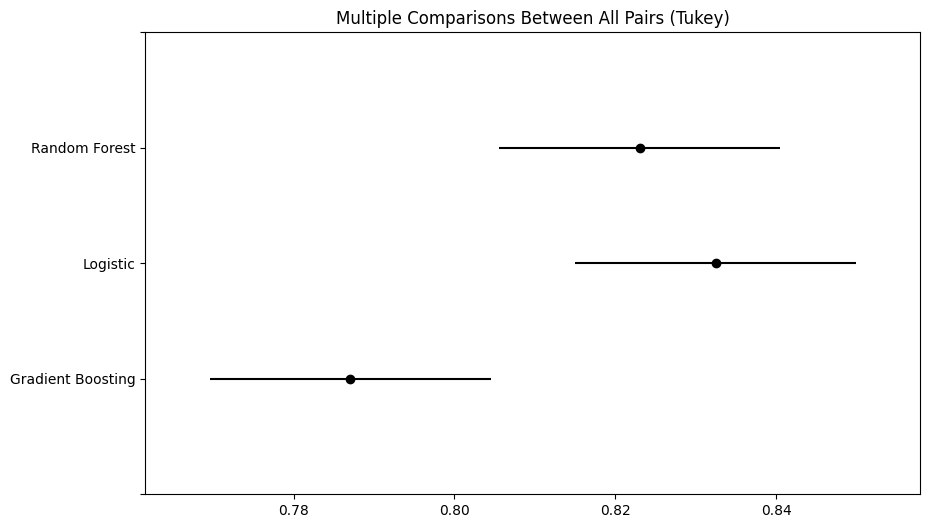

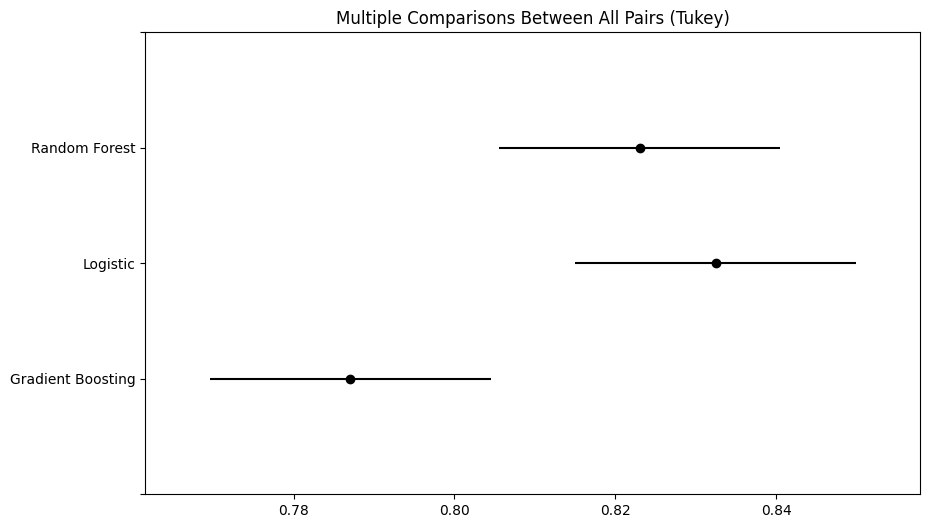

In [ ]:
tukey_result.plot_simultaneous()

***8.2 Friedman***

In [ ]:
friedman_result = friedmanchisquare(scores_log, scores_rf, scores_gb)
print(friedman_result)

FriedmanchisquareResult(statistic=np.float64(20.0121212121212), pvalue=np.float64(4.512561078231813e-05))


Los scores de validación cruzada se tratan como observaciones dependientes aproximadas, razón por la cual se incluye una prueba no paramétrica.

**9. Matrices de confusion**

Las matrices de confusión permiten analizar detalladamente el comportamiento de los modelos en términos de verdaderos y falsos positivos y negativos, aspecto especialmente relevante en contextos clínicos donde los errores de clasificación tienen implicaciones diagnósticas.

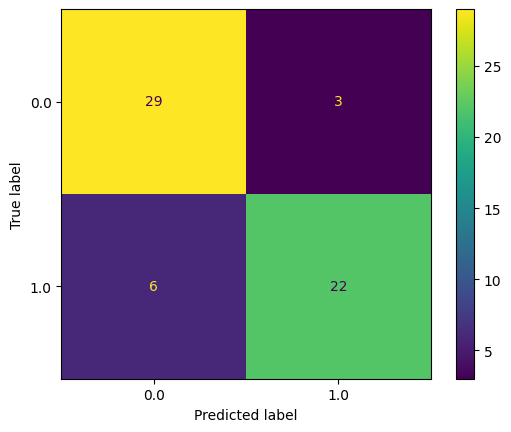

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# División estratificada para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

pipeline_rf.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(pipeline_rf, X_test, y_test)
plt.savefig("confusion_rf.png", dpi=300)
plt.show()

***9.1 Regresion Logistica***

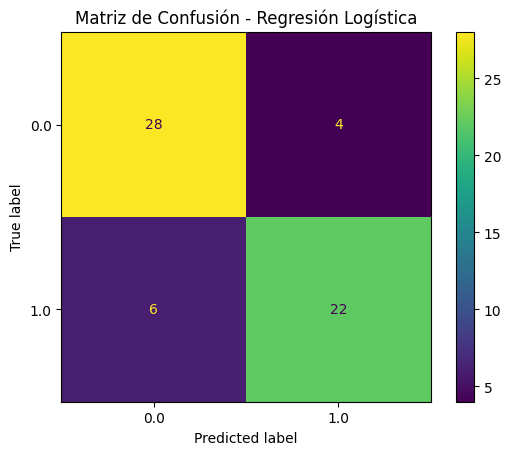

In [ ]:
# ==========================
# MATRIZ DE CONFUSIÓN - REGRESIÓN LOGÍSTICA
# ==========================

pipeline_log.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    pipeline_log,
    X_test,
    y_test
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.savefig("confusion_logistic.png", dpi=300)
plt.show()

***9.2 Random Forest***

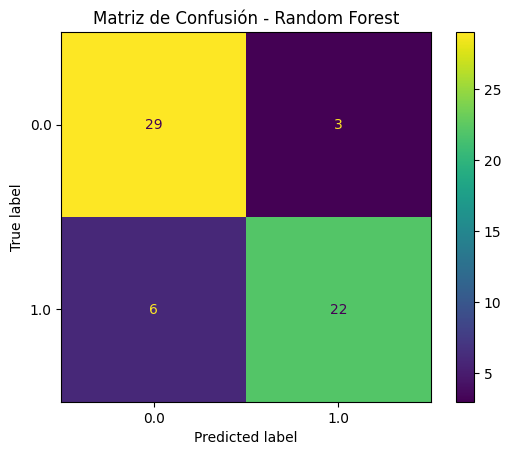

In [ ]:
# ==========================
# MATRIZ DE CONFUSIÓN - RANDOM FOREST
# ==========================

pipeline_rf.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    pipeline_rf,
    X_test,
    y_test
)

plt.title("Matriz de Confusión - Random Forest")
plt.savefig("confusion_rf.png", dpi=300)
plt.show()

***9.3 Gradient Boosting***

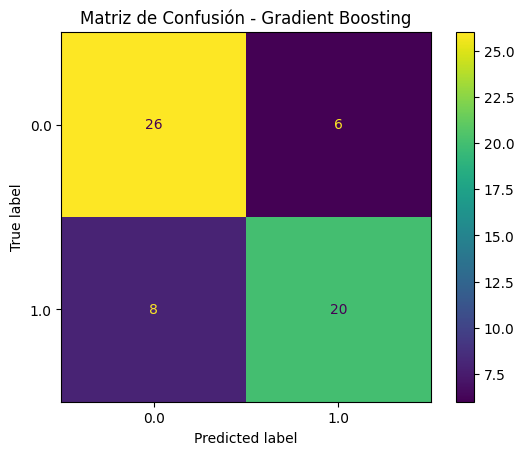

In [ ]:
# ==========================
# MATRIZ DE CONFUSIÓN - GRADIENT BOOSTING
# ==========================

pipeline_gb.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    pipeline_gb,
    X_test,
    y_test
)

plt.title("Matriz de Confusión - Gradient Boosting")
plt.savefig("confusion_gb.png", dpi=300)
plt.show()

**9.4 Regresión Logística (Normalizada)**

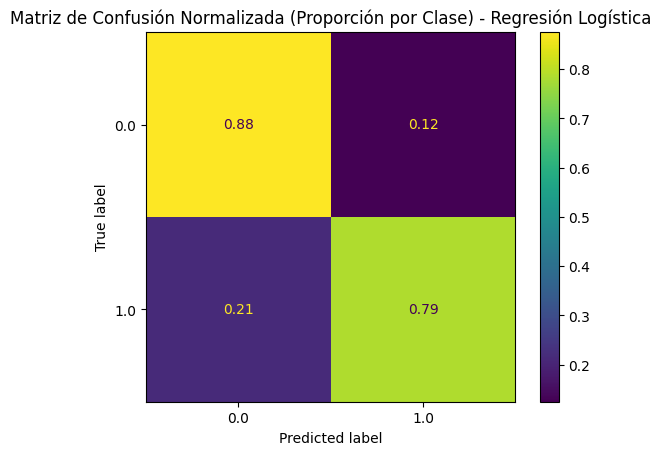

In [ ]:
# ==========================
# MATRIZ NORMALIZADA - REGRESIÓN LOGÍSTICA
# ==========================

ConfusionMatrixDisplay.from_estimator(
    pipeline_log,
    X_test,
    y_test,
    normalize='true'
)

plt.title("Matriz de Confusión Normalizada (Proporción por Clase) - Regresión Logística")
plt.savefig("confusion_logistic_normalizada.png", dpi=300)
plt.show()

**9.5 Random Forest (Normalizada)**

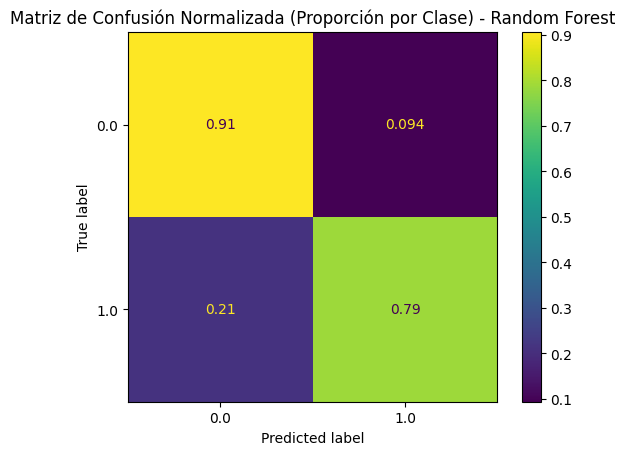

In [ ]:
# ==========================
# MATRIZ NORMALIZADA - RANDOM FOREST
# ==========================

ConfusionMatrixDisplay.from_estimator(
    pipeline_rf,
    X_test,
    y_test,
    normalize='true'
)

plt.title("Matriz de Confusión Normalizada (Proporción por Clase) - Random Forest")
plt.savefig("confusion_rf_normalizada.png", dpi=300)
plt.show()

**9.6 Gradient Boosting (Normalizada)**

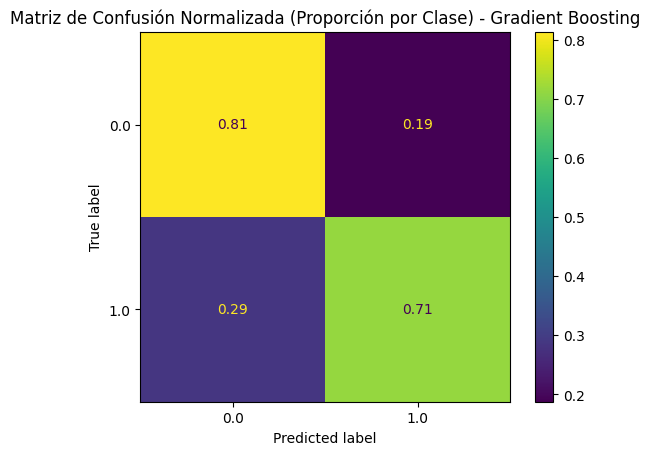

In [ ]:
# ==========================
# MATRIZ NORMALIZADA - GRADIENT BOOSTING
# ==========================

ConfusionMatrixDisplay.from_estimator(
    pipeline_gb,
    X_test,
    y_test,
    normalize='true'
)

plt.title("Matriz de Confusión Normalizada (Proporción por Clase) - Gradient Boosting")
plt.savefig("confusion_gb_normalizada.png", dpi=300)
plt.show()

**10. Desviación estandar e Intervalo de Confianza**

In [ ]:
from scipy import stats

def resumen_metricas(scores, alpha=0.05):
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    n = len(scores)
    se = std / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se
    return mean, std, ci_low, ci_high

resumen = pd.DataFrame({
    "Logistic": resumen_metricas(scores_log),
    "RandomForest": resumen_metricas(scores_rf),
    "GradientBoosting": resumen_metricas(scores_gb)
}, index=["Mean","Std","CI_low","CI_high"])

resumen.to_csv("tabla_metricas_con_ic.csv")
resumen

,Logistic,RandomForest,GradientBoosting
Mean,0.832483,0.823034,0.787057
Std,0.069459,0.076957,0.074288
CI_low,0.812743,0.801164,0.765945
CI_high,0.852223,0.844905,0.808170


**11. Tamaño del efecto (`η²`)**

Adicionalmente, se estimó el tamaño del efecto mediante eta cuadrado (η²), lo que permite cuantificar la proporción de la variabilidad total del desempeño explicada por el tipo de modelo utilizado. Este indicador complementa el análisis de significancia estadística, aportando una interpretación práctica de la magnitud de las diferencias observadas.

In [ ]:
from scipy.stats import f_oneway

anova_result = f_oneway(scores_log, scores_rf, scores_gb)

F = anova_result.statistic
df_between = 2
df_within = (len(scores_log) * 3) - 3

eta_squared = (F * df_between) / ((F * df_between) + df_within)

print("F =", F)
print("Eta squared =", eta_squared)

F = 5.298093084593742
Eta squared = 0.06723631089531533


**12. Tabla correlacion Pearson**

Estas correlaciones se reportan con fines exploratorios y no implican relaciones causales.

In [ ]:
from scipy.stats import pearsonr

correlations = {}

for col in X.columns:
    r, p = pearsonr(data[col], y)
    correlations[col] = {"r": r, "p_value": p}

corr_df = pd.DataFrame(correlations).T.sort_values(by="r", ascending=False)
corr_df.to_csv("tabla_correlaciones_pearson.csv")
corr_df

,r,p_value
thal,0.526640,1.359456e-22
ca,0.463189,3.358947e-17
oldpeak,0.424052,2.159737e-14
exang,0.421355,3.272490e-14
cp,0.408945,2.113493e-13
slope,0.333049,3.997425e-09
sex,0.278467,1.085076e-06
age,0.227075,7.862868e-05
restecg,0.166343,4.044406e-03
trestbps,0.153490,8.054796e-03


**13. Importancia de variables**

In [ ]:
pipeline_rf.fit(X, y)

importances = pd.Series(
    pipeline_rf.named_steps['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.to_csv("tabla_importancia_rf.csv")
importances

,0
thalach,0.123176
thal,0.120980
cp,0.119219
ca,0.117524
oldpeak,0.105544
age,0.101294
trestbps,0.074835
chol,0.072463
exang,0.053397
slope,0.048968


**14. Visualización comparativa del desempeño de modelos**

***14.1 Métricas de desempeño en conjunto de prueba independiente***

Con el fin de complementar los resultados obtenidos mediante validación cruzada, se evaluó el desempeño de los modelos en un conjunto de prueba independiente. Esta evaluación permite ilustrar el comportamiento de los clasificadores en un escenario clínico simulado, así como calcular métricas específicas como sensibilidad, especificidad y AUC. Es importante destacar que estos resultados no se utilizan para inferencia estadística, sino como apoyo interpretativo a los análisis robustos basados en validación cruzada.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve
)
def evaluar_modelo(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Sensitivity": recall_score(y_test, y_pred),
        "Specificity": recall_score(y_test, y_pred, pos_label=0),
        "AUC": roc_auc_score(y_test, y_prob)
    }

results = {
    "Regresión logística": evaluar_modelo(pipeline_log),
    "Random Forest": evaluar_modelo(pipeline_rf),
    "Gradient Boosting": evaluar_modelo(pipeline_gb)
}

results_df = pd.DataFrame(results).T
results_df.to_csv("tabla_metricas_testset.csv")
results_df

,Accuracy,Sensitivity,Specificity,AUC
Regresión logística,0.833333,0.785714,0.87500,0.949777
Random Forest,0.850000,0.785714,0.90625,0.940848
Gradient Boosting,0.766667,0.714286,0.81250,0.882812


***14.2 Gráfico comparativo de métricas***

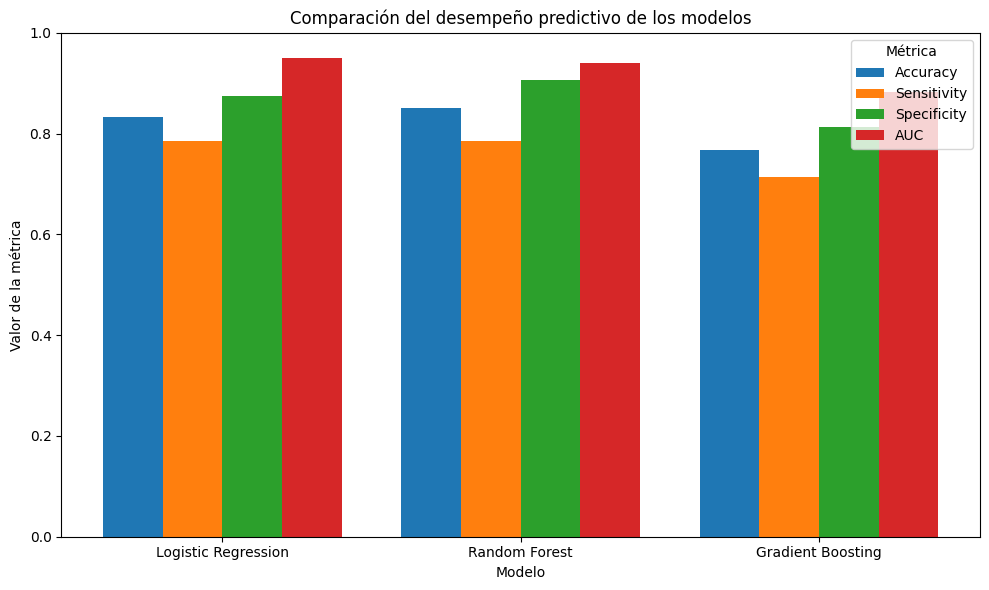

In [ ]:
# Configuración
metrics = results_df.columns
models = results_df.index
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xticks(x + width*1.5, models)
plt.ylim(0, 1)
plt.ylabel("Valor de la métrica")
plt.xlabel("Modelo")
plt.title("Comparación del desempeño predictivo de los modelos")
plt.legend(title="Métrica")

plt.tight_layout()
plt.savefig("comparacion_metricas_modelos.png", dpi=300)
plt.show()

**15. Curva ROC**

Estimadas sobre un conjunto de prueba independiente y no utilizadas para inferencia estadística.

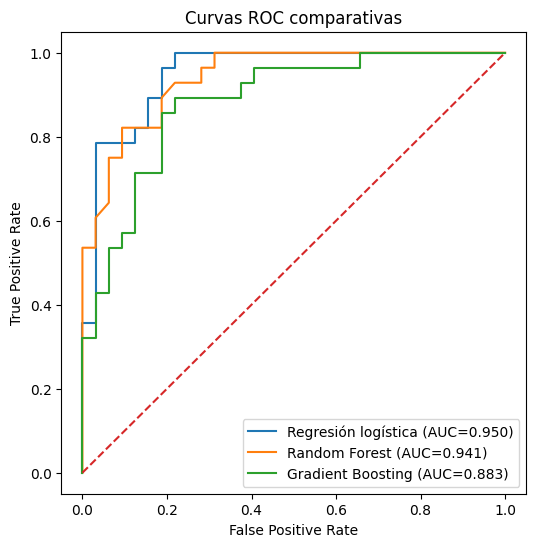

In [ ]:
plt.figure(figsize=(6,6))

for name, model in {
    "Regresión logística": pipeline_log,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gb
}.items():

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC comparativas")
plt.legend()
plt.savefig("roc_comparativa.png", dpi=300)
plt.show()

**16. Calibracion**

Además de la capacidad discriminativa, se evaluó la calibración probabilística de los modelos, entendida como la concordancia entre las probabilidades predichas y las frecuencias observadas. La calibración es un aspecto crítico para la toma de decisiones clínicas basadas en riesgo.

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

**17. Calculo curvas de calibracion y Brier Score**

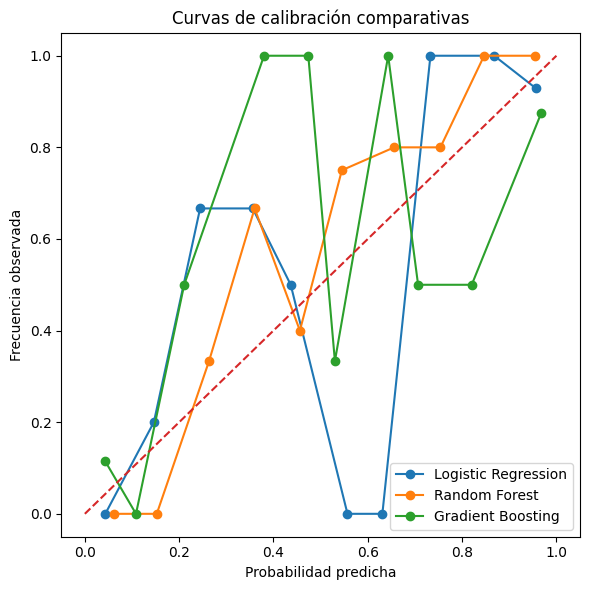

In [ ]:
models_dict = {
    "Logistic Regression": pipeline_log,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gb
}

brier_results = {}

plt.figure(figsize=(6,6))

for name, model in models_dict.items():

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]

    # Curva de calibración
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o', label=name)

    # Brier Score
    brier_results[name] = brier_score_loss(y_test, probs)

# Línea de calibración perfecta
plt.plot([0,1],[0,1],'--')

plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.title("Curvas de calibración comparativas")
plt.legend()
plt.tight_layout()
plt.savefig("curvas_calibracion_modelos.png", dpi=300)
plt.show()

**18. Tabla de Brier Score**

In [ ]:
brier_df = pd.Series(brier_results, name="Brier Score")
brier_df.to_csv("tabla_brier_score.csv")
brier_df

,Brier Score
Logistic Regression,0.093786
Random Forest,0.107668
Gradient Boosting,0.147588


## **Conclusión**

Los resultados del análisis evidencian que todos los modelos evaluados presentan una capacidad discriminativa adecuada para la predicción de enfermedad cardíaca, con valores de AUC superiores a 0.85. La regresión logística destacó por su mayor estabilidad y mejor calibración probabilística, lo que la convierte en una alternativa particularmente adecuada en contextos clínicos donde la interpretabilidad y la confiabilidad de las probabilidades predichas son prioritarias.

Los modelos basados en árboles mostraron un desempeño competitivo, aunque con mayor variabilidad entre particiones y menor ajuste probabilístico. Si bien las diferencias observadas resultaron estadísticamente significativas, el tamaño del efecto fue pequeño a moderado, lo que sugiere que el incremento en complejidad algorítmica no se traduce necesariamente en mejoras sustanciales en este conjunto de datos específico.

En conjunto, estos hallazgos respaldan la importancia de equilibrar desempeño predictivo, estabilidad, interpretabilidad y calibración al seleccionar modelos de aprendizaje automático para aplicaciones clínicas.
Estos resultados deben interpretarse en el contexto del tamaño muestral y la naturaleza observacional del conjunto de datos.

***Notas metodológicas y referencias técnicas***

>Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python.

>UCI Machine Learning Repository – Heart Disease Dataset.

>Hanley & McNeil (1982). The meaning and use of the area under the ROC curve.

**Autor:**

[Leon, E.](https://)